In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Data


In [3]:
df=pd.read_csv("zomato_bangalore.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'zomato_bangalore.csv'

### 2. Explore Data

In [ ]:
print(df.head())

   restaurant_id           restaurant_name      location  \
0              1          Shree Chai Shack     Jayanagar   
1              2        Café Noodle Corner        Hebbal   
2              3  The Grand Saffron Palace     Bellandur   
3              4        The Grand Idli Hub  Malleshwaram   
4              5            Café Basil Hub  Kammanahalli   

                                 cuisine  avg_cost_for_two  aggregate_rating  \
0                           North Indian               NaN               4.0   
1                              Fast Food               NaN               4.5   
2       Fast Food, Chinese, South Indian             964.0               2.5   
3                        Italian, Andhra             822.0               3.0   
4  Italian, Bakery, Kerala, North Indian            1110.0               3.0   

    votes approx_price has_table_booking has_online_delivery restaurant_type  \
0  2083.0          NaN               Yes                 Yes          Dining  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   restaurant_id        100000 non-null  int64  
 1   restaurant_name      100000 non-null  object 
 2   location             100000 non-null  object 
 3   cuisine              100000 non-null  object 
 4   avg_cost_for_two     95000 non-null   float64
 5   aggregate_rating     92900 non-null   float64
 6   votes                93032 non-null   float64
 7   approx_price         95000 non-null   object 
 8   has_table_booking    100000 non-null  object 
 9   has_online_delivery  100000 non-null  object 
 10  restaurant_type      100000 non-null  object 
 11  reviews_list         100000 non-null  object 
 12  menu_items           100000 non-null  object 
 13  opening_hours        100000 non-null  object 
 14  city                 100000 non-null  object 
 15  has_zomato_pro    

In [ ]:
print(df.isnull().sum())

restaurant_id             0
restaurant_name           0
location                  0
cuisine                   0
avg_cost_for_two       5000
aggregate_rating       7100
votes                  6968
approx_price           5000
has_table_booking         0
has_online_delivery       0
restaurant_type           0
reviews_list              0
menu_items                0
opening_hours             0
city                      0
has_zomato_pro            0
address                   0
dtype: int64


In [ ]:
df.shape

(100000, 17)

In [ ]:
df.describe()

,restaurant_id,avg_cost_for_two,aggregate_rating,votes
count,100000.000000,95000.000000,92900.000000,93032.000000
mean,50000.500000,1097.082600,3.700027,3094.148272
std,28867.657797,1067.666397,0.488677,1439.663720
min,1.000000,150.000000,1.500000,10.000000
25%,25000.750000,401.000000,3.500000,2173.000000
50%,50000.500000,763.000000,3.500000,2933.000000
75%,75000.250000,1238.250000,4.000000,3775.000000
max,100000.000000,7998.000000,5.000000,9999.000000


#### 3. Remove rows with missing critical columns

In [ ]:
df_clean = df.dropna(subset=['aggregate_rating', 'avg_cost_for_two', 'votes'])
print(f"After removing missing ratings/cost/votes: {len(df_clean):,} rows")

After removing missing ratings/cost/votes: 82,135 rows


#### 4. Clean approx_price column (remove commas and convert)

In [ ]:
df_clean['approx_price'] = df_clean['approx_price'].astype(str).str.replace(',', '')
df_clean['approx_price'] = pd.to_numeric(df_clean['approx_price'], errors='coerce')
print(df_clean)

       restaurant_id           restaurant_name        location  \
2                  3  The Grand Saffron Palace       Bellandur   
3                  4        The Grand Idli Hub    Malleshwaram   
4                  5            Café Basil Hub    Kammanahalli   
5                  6        Café Masala Studio    Marathahalli   
6                  7      Little Saffron Plate  CV Raman Nagar   
...              ...                       ...             ...   
99994          99995        Café Saffron Point   Richmond Town   
99995          99996      Spice Biryani Corner      HSR Layout   
99997          99998        Shree Grill Palace        RT Nagar   
99998          99999        Royal Mango Palace      HSR Layout   
99999         100000            Dilli Rice Box         MG Road   

                                             cuisine  avg_cost_for_two  \
2                   Fast Food, Chinese, South Indian             964.0   
3                                    Italian, Andhra       

C:\Users\HP\AppData\Local\Temp\ipykernel_11820\4260883645.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['approx_price'] = df_clean['approx_price'].astype(str).str.replace(',', '')
C:\Users\HP\AppData\Local\Temp\ipykernel_11820\4260883645.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['approx_price'] = pd.to_numeric(df_clean['approx_price'], errors='coerce')


#### 5. Filter valid ratings (0-5)

In [ ]:
df_clean=df_clean[(df_clean['aggregate_rating'] >= 0) & (df_clean['aggregate_rating'] <= 5)]
print(f"After filtering valid ratings: {len(df_clean):,} rows")

NameError: name 'df_clean' is not defined

#### 6. Convert binary columns to numeric

In [ ]:
df_clean['has_table_booking_num']=df_clean['has_table_booking'].map({'Yes': 1, 'No': 0})

df_clean['has_online_delivery_num']=df_clean['has_online_delivery'].map({'Yes': 1, 'No': 0})

df_clean['has_zomato_pro_num']=df_clean['has_zomato_pro'].map({'Yes': 1, 'No': 0})

print(f"CLEAN DATASET:{len(df_clean):,} rows")

CLEAN DATASET:82,135 rows


#### 7. UNIVARIATE ANALYSIS

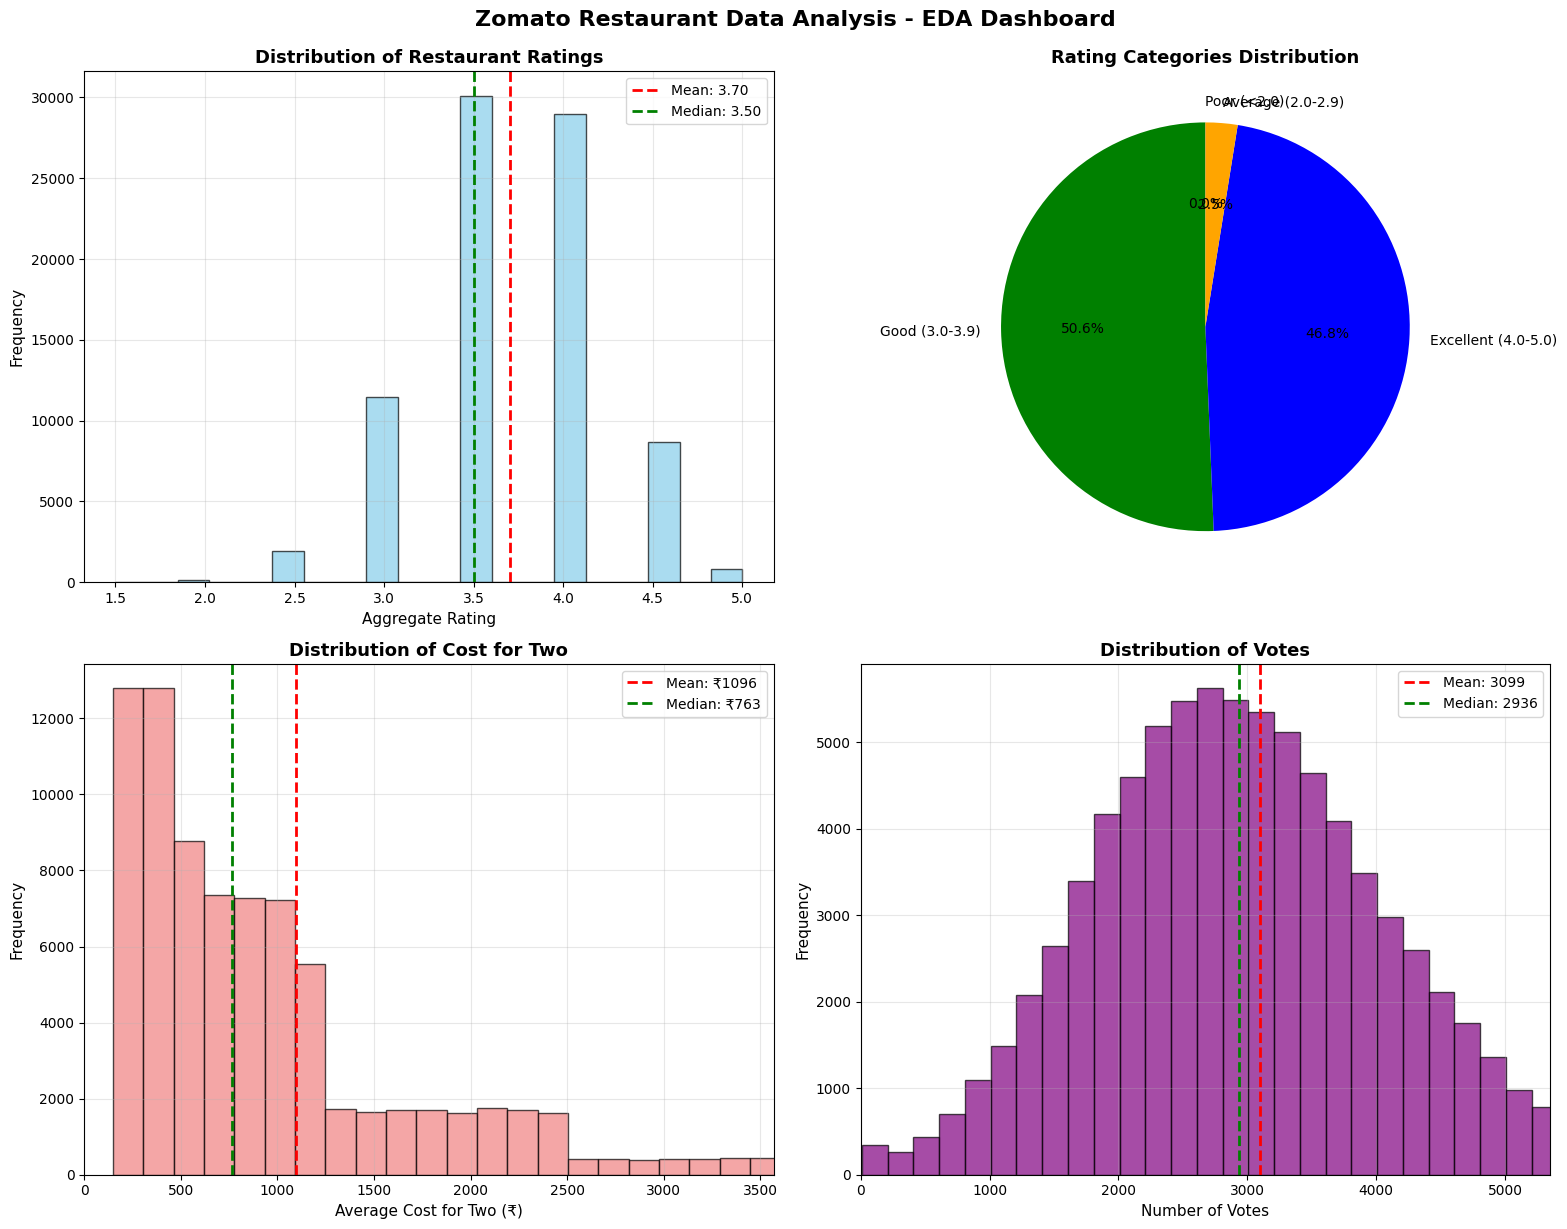

In [ ]:
# ============================================
# PLOT 1: Rating Distribution (Top-Left)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0,0].hist(df_clean['aggregate_rating'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)

axes[0,0].axvline(df_clean['aggregate_rating'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["aggregate_rating"].mean():.2f}')

axes[0,0].axvline(df_clean['aggregate_rating'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_clean["aggregate_rating"].median():.2f}')

axes[0,0].set_xlabel('Aggregate Rating', fontsize=11)
axes[0,0].set_ylabel('Frequency', fontsize=11)
axes[0,0].set_title('Distribution of Restaurant Ratings', fontsize=13, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ====================================================
# PLOT 2: Rating Categories Pie Chart (Top-Right)
# ====================================================
def rating_category(rating):
    if rating >= 4.0:
        return 'Excellent (4.0-5.0)'
    elif rating >= 3.0:
        return 'Good (3.0-3.9)'
    elif rating >= 2.0:
        return 'Average (2.0-2.9)'
    else:
        return 'Poor (<2.0)'

df_clean['rating_category'] = df_clean['aggregate_rating'].apply(rating_category)
category_counts = df_clean['rating_category'].value_counts()
colors = ['green', 'blue', 'orange', 'red']

axes[0, 1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)

axes[0, 1].set_title('Rating Categories Distribution', fontsize=13, fontweight='bold')

# ============================================
# PLOT 3: Cost Distribution (Bottom-Left)
# ============================================
axes[1,0].hist(df_clean['avg_cost_for_two'], bins=50, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1,0].set_xlabel('Average Cost for Two (₹)', fontsize=11)
axes[1,0].set_ylabel('Frequency', fontsize=11)
axes[1,0].set_title('Distribution of Cost for Two', fontsize=13, fontweight='bold')
axes[1,0].set_xlim(0, df_clean['avg_cost_for_two'].quantile(0.95))
axes[1,0].grid(True, alpha=0.3)

# Add mean and median lines for cost
mean_cost = df_clean['avg_cost_for_two'].mean()
median_cost = df_clean['avg_cost_for_two'].median()

axes[1,0].axvline(mean_cost, color='red', linestyle='--', linewidth=2, label=f'Mean: ₹{mean_cost:.0f}')

axes[1,0].axvline(median_cost, color='green', linestyle='--', linewidth=2, label=f'Median: ₹{median_cost:.0f}')
axes[1,0].legend()

# ============================================
# PLOT 4: Votes Distribution (Bottom-Right)
# ============================================
axes[1,1].hist(df_clean['votes'], bins=50, edgecolor='black', color='purple', alpha=0.7)
axes[1,1].set_xlabel('Number of Votes', fontsize=11)
axes[1,1].set_ylabel('Frequency', fontsize=11)
axes[1,1].set_title('Distribution of Votes', fontsize=13, fontweight='bold')
axes[1,1].set_xlim(0, df_clean['votes'].quantile(0.95))
axes[1,1].grid(True, alpha=0.3)

# Add mean and median lines for votes
mean_votes = df_clean['votes'].mean()
median_votes = df_clean['votes'].median()
axes[1,1].axvline(mean_votes, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_votes:.0f}')

axes[1,1].axvline(median_votes, color='green', linestyle='--', linewidth=2, label=f'Median: {median_votes:.0f}')
axes[1,1].legend()

# ============================================
# FINAL: Adjust layout and SHOW
# ============================================
plt.tight_layout()  # Prevents overlapping
plt.suptitle('Zomato Restaurant Data Analysis - EDA Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.show()

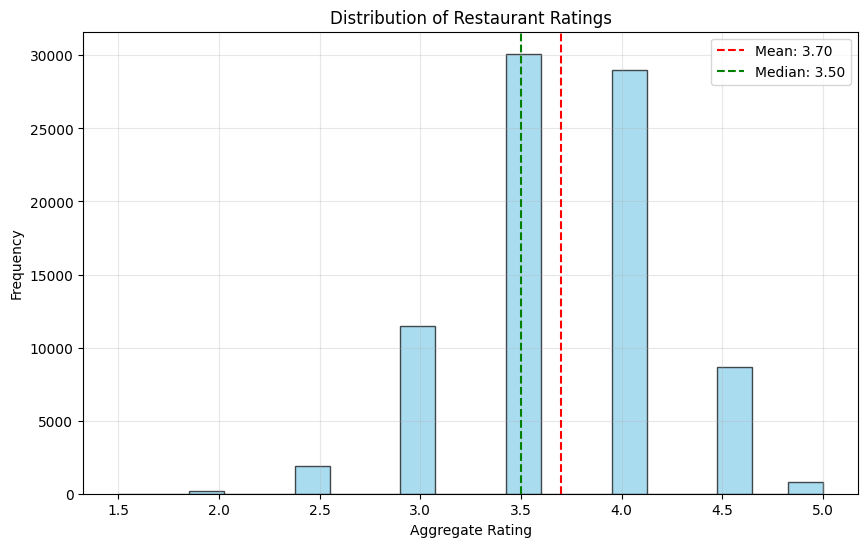

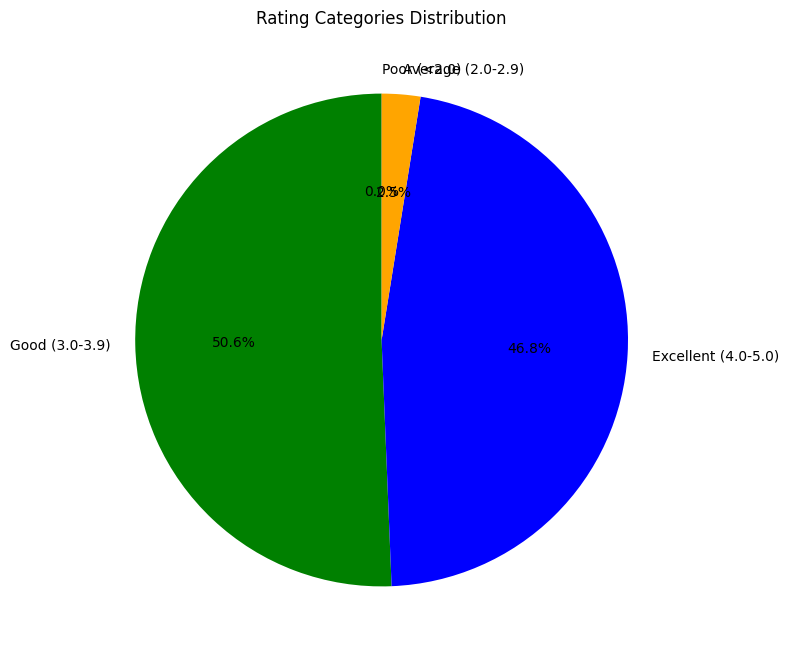

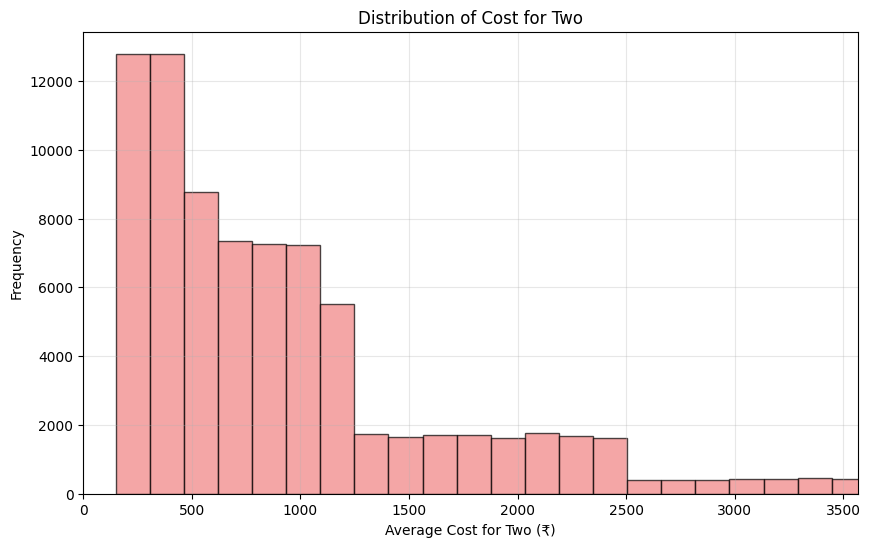

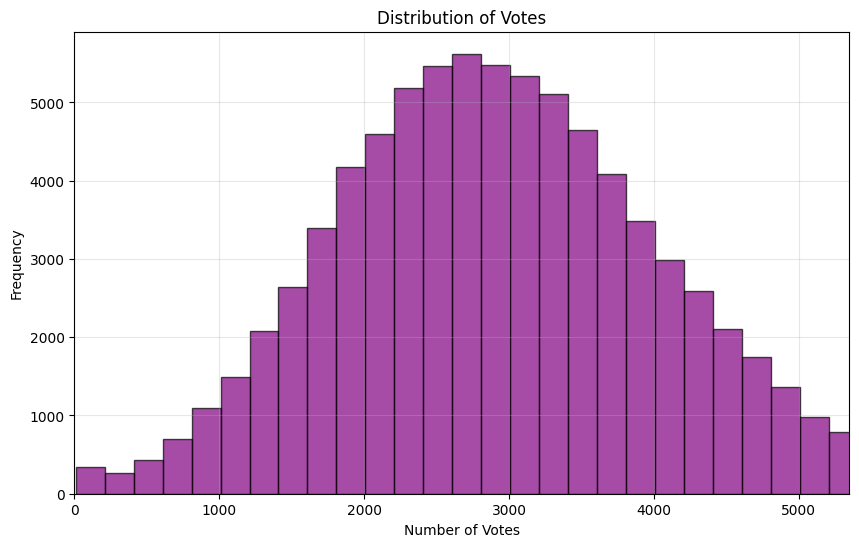

In [ ]:
# Chart 1: Rating Histogram
plt.figure(figsize=(10,6))
plt.hist(df_clean['aggregate_rating'], bins=20, edgecolor='black', color='skyblue', alpha=0.7)
plt.axvline(df_clean['aggregate_rating'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["aggregate_rating"].mean():.2f}')
plt.axvline(df_clean['aggregate_rating'].median(), color='green', linestyle='--', label=f'Median: {df_clean["aggregate_rating"].median():.2f}')
plt.xlabel('Aggregate Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Restaurant Ratings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Chart 2: Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Rating Categories Distribution')
plt.show()

# Chart 3: Cost Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_clean['avg_cost_for_two'], bins=50, edgecolor='black', color='lightcoral', alpha=0.7)
plt.xlabel('Average Cost for Two (₹)')
plt.ylabel('Frequency')
plt.title('Distribution of Cost for Two')
plt.xlim(0, df_clean['avg_cost_for_two'].quantile(0.95))
plt.grid(True, alpha=0.3)
plt.show()

# Chart 4: Votes Distribution
plt.figure(figsize=(10, 6))
plt.hist(df_clean['votes'], bins=50, edgecolor='black', color='purple', alpha=0.7)
plt.xlabel('Number of Votes')
plt.ylabel('Frequency')
plt.title('Distribution of Votes')
plt.xlim(0, df_clean['votes'].quantile(0.95))
plt.grid(True, alpha=0.3)
plt.show()

#### 9. CATEGORICAL ANALYSIS

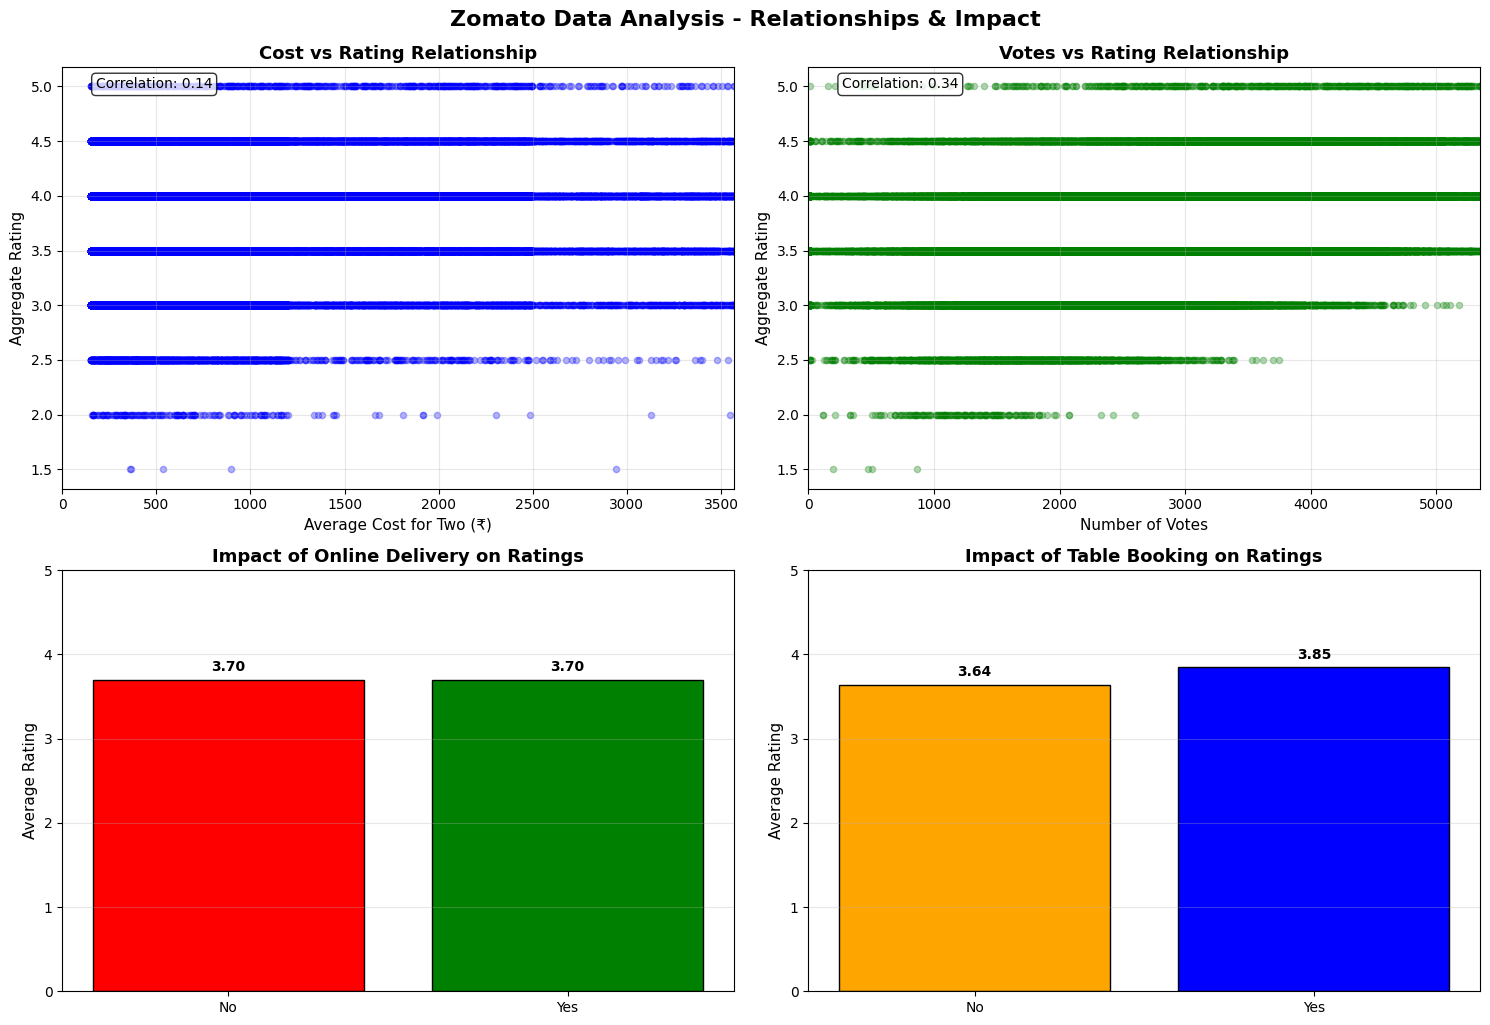

In [ ]:
# ============================================
# PLOT 1: Cost vs Rating (Top-Left)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes[0,0].scatter(df_clean['avg_cost_for_two'], df_clean['aggregate_rating'], alpha=0.3, s=20, color='blue')
axes[0,0].set_xlabel('Average Cost for Two (₹)', fontsize=11)
axes[0,0].set_ylabel('Aggregate Rating', fontsize=11)
axes[0,0].set_title('Cost vs Rating Relationship', fontsize=13, fontweight='bold')
axes[0,0].set_xlim(0, df_clean['avg_cost_for_two'].quantile(0.95))
axes[0,0].grid(True, alpha=0.3)

# Add correlation value
corr_cost = df_clean['avg_cost_for_two'].corr(df_clean['aggregate_rating'])
axes[0,0].text(0.05, 0.95, f'Correlation: {corr_cost:.2f}', transform=axes[0, 0].transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================
# PLOT 2: Votes vs Rating (Top-Right)
# ============================================

axes[0,1].scatter(df_clean['votes'], df_clean['aggregate_rating'], alpha=0.3, s=20, color='green')
axes[0,1].set_xlabel('Number of Votes', fontsize=11)
axes[0,1].set_ylabel('Aggregate Rating', fontsize=11)
axes[0,1].set_title('Votes vs Rating Relationship', fontsize=13, fontweight='bold')
axes[0,1].set_xlim(0, df_clean['votes'].quantile(0.95))
axes[0,1].grid(True, alpha=0.3)

# Add correlation value
corr_votes = df_clean['votes'].corr(df_clean['aggregate_rating'])
axes[0, 1].text(0.05, 0.95, f'Correlation: {corr_votes:.2f}', transform=axes[0, 1].transAxes, fontsize=10,bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================
# PLOT 3: Online Delivery Impact (Bottom-Left)
# ============================================
# Check if column exists and handle values
if 'has_online_delivery' in df_clean.columns:
    online_means = df_clean.groupby('has_online_delivery')['aggregate_rating'].mean()
    
    # Handle different value types (Yes/No, True/False, 1/0)
    labels = online_means.index.tolist()
    if True in labels or False in labels:
        labels = ['No Online Delivery' if x == False else 'Has Online Delivery' for x in labels]
    elif 0 in labels or 1 in labels:
        labels = ['No Online Delivery' if x == 0 else 'Has Online Delivery' for x in labels]
    else:
        labels = labels
    
    axes[1,0].bar(labels, online_means.values, color=['red', 'green'], edgecolor='black')
    axes[1,0].set_ylabel('Average Rating', fontsize=11)
    axes[1,0].set_title('Impact of Online Delivery on Ratings', fontsize=13, fontweight='bold')
    axes[1,0].set_ylim(0, 5)
    
    for i, v in enumerate(online_means.values):
        axes[1, 0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
else:
    axes[1, 0].text(0.5, 0.5, "Column 'has_online_delivery' not found", ha='center', transform=axes[1, 0].transAxes)

# ============================================
# PLOT 4: Table Booking Impact (Bottom-Right)
# ============================================

if 'has_table_booking' in df_clean.columns:
    table_means = df_clean.groupby('has_table_booking')['aggregate_rating'].mean()
    
    # Handle different value types
    labels = table_means.index.tolist()
    if True in labels or False in labels:
        labels = ['No Table Booking' if x == False else 'Has Table Booking' for x in labels]
    elif 0 in labels or 1 in labels:
        labels = ['No Table Booking' if x == 0 else 'Has Table Booking' for x in labels]
    else:
        labels = labels
    
    axes[1,1].bar(labels, table_means.values, color=['orange', 'blue'], edgecolor='black')
    axes[1,1].set_ylabel('Average Rating', fontsize=11)
    axes[1,1].set_title('Impact of Table Booking on Ratings', fontsize=13, fontweight='bold')
    axes[1,1].set_ylim(0, 5)
    
    for i, v in enumerate(table_means.values):
        axes[1,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
    axes[1,1].grid(True, alpha=0.3, axis='y')
else:
    axes[1,1].text(0.5, 0.5, "Column 'has_table_booking' not found", ha='center', transform=axes[1, 1].transAxes)

# ============================================
# FINAL: Adjust layout and SHOW
# ============================================

plt.tight_layout()
plt.suptitle('Zomato Data Analysis - Relationships & Impact', fontsize=16, fontweight='bold', y=1.02)
plt.show()


#### 10.  MULTIVARIATE ANALYSIS

C:\Users\HP\AppData\Local\Temp\ipykernel_11820\4033157895.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_segment', y='aggregate_rating', data=df_clean, ax=axes[1], palette='Set2')


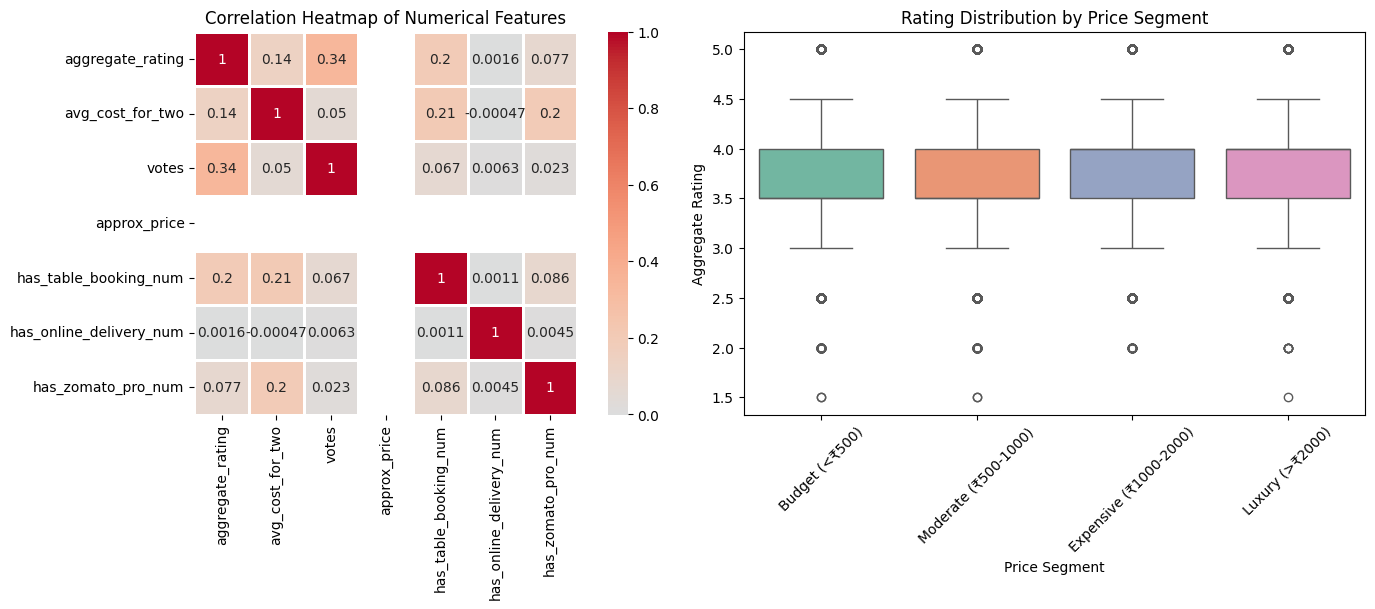

In [ ]:
# Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
numeric_cols = ['aggregate_rating', 'avg_cost_for_two', 'votes', 'approx_price','has_table_booking_num', 'has_online_delivery_num', 'has_zomato_pro_num']
corr_matrix = df_clean[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, ax=axes[0])
axes[0].set_title('Correlation Heatmap of Numerical Features')

# Boxplot - Rating by Price Segment
df_clean['price_segment'] = pd.cut(df_clean['avg_cost_for_two'], bins=[0, 500, 1000, 2000, 50000], labels=['Budget (<₹500)', 'Moderate (₹500-1000)', 'Expensive (₹1000-2000)', 'Luxury (>₹2000)'])
sns.boxplot(x='price_segment', y='aggregate_rating', data=df_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Rating Distribution by Price Segment')
axes[1].set_xlabel('Price Segment')
axes[1].set_ylabel('Aggregate Rating')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11820\2506569427.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='city', y='aggregate_rating', data=df_top5_cities, ax=axes[0], palette='Set3')


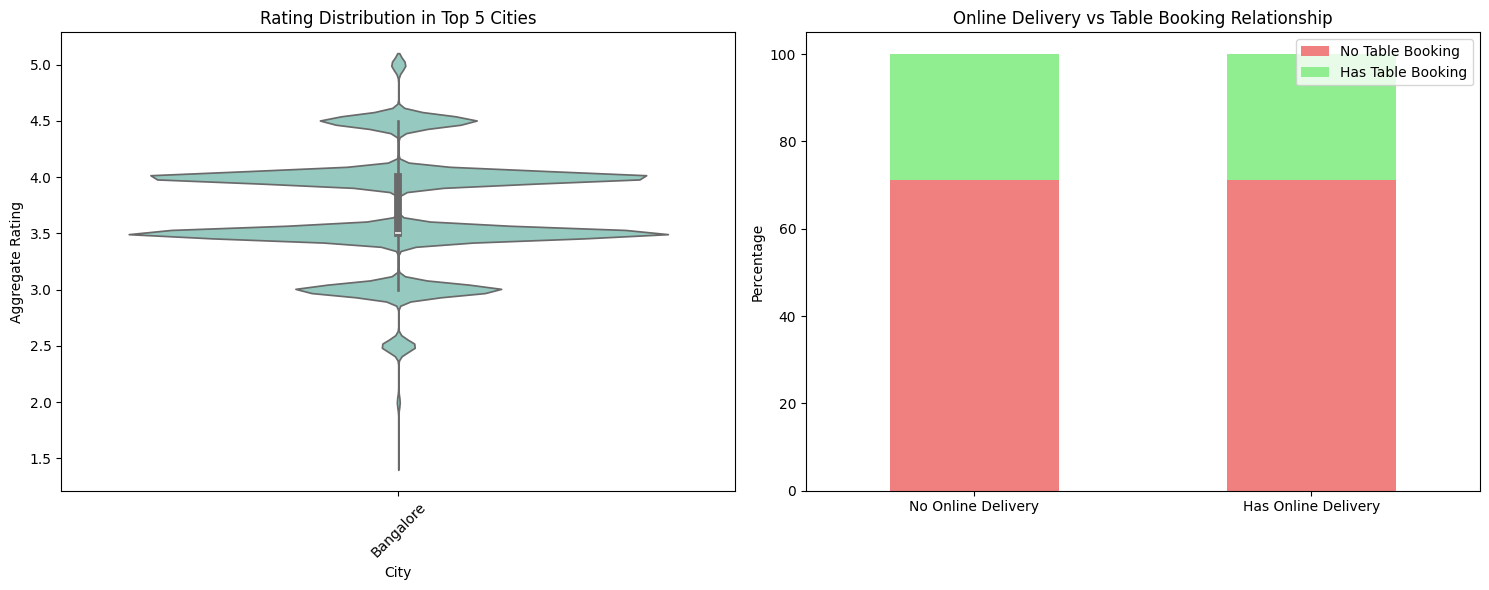


⭐ ZOMATO PRO IMPACT ON RATINGS:
                    mean  count  median
No Zomato Pro   3.674060  55254     3.5
Has Zomato Pro  3.754604  26881     4.0

💰 BEST VALUE FOR MONEY RESTAURANTS (Rating per ₹100):
       restaurant_name      city  aggregate_rating  avg_cost_for_two  value_score
    Hotel Rice Kitchen Bangalore               5.0             150.0        3.333
    Spice Spice Studio Bangalore               5.0             151.0        3.311
    Dilli Masala House Bangalore               5.0             155.0        3.226
  Bombay Masala Garden Bangalore               5.0             155.0        3.226
       Café Brew Plate Bangalore               5.0             156.0        3.205
  Bombay Masala Lounge Bangalore               5.0             157.0        3.185
       Biryani Express Bangalore               5.0             159.0        3.145
  Bombay Masala Lounge Bangalore               5.0             160.0        3.125
Green Turmeric Express Bangalore               5.0    

In [ ]:
# 8.1 Rating distribution by City (Top 5 cities)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top5_cities = df_clean['city'].value_counts().head(5).index
df_top5_cities = df_clean[df_clean['city'].isin(top5_cities)]
sns.violinplot(x='city', y='aggregate_rating', data=df_top5_cities, ax=axes[0], palette='Set3')
axes[0].set_title('Rating Distribution in Top 5 Cities')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Aggregate Rating')
axes[0].tick_params(axis='x', rotation=45)

# 8.2 Online Delivery vs Table Booking
delivery_table = pd.crosstab(df_clean['has_online_delivery'], df_clean['has_table_booking'], normalize='index') * 100
delivery_table.columns = ['No Table Booking', 'Has Table Booking']
delivery_table.index = ['No Online Delivery', 'Has Online Delivery']
delivery_table.plot(kind='bar', stacked=True, ax=axes[1], color=['lightcoral', 'lightgreen'])
axes[1].set_title('Online Delivery vs Table Booking Relationship')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('')
axes[1].legend(loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 8.3 Zomato Pro Analysis
print("\n⭐ ZOMATO PRO IMPACT ON RATINGS:")
zomato_stats = df_clean.groupby('has_zomato_pro')['aggregate_rating'].agg(['mean', 'count', 'median'])
zomato_stats.index = ['No Zomato Pro', 'Has Zomato Pro']
print(zomato_stats)

# 8.4 Cost Efficiency Score
print("\n💰 BEST VALUE FOR MONEY RESTAURANTS (Rating per ₹100):")
df_clean['value_score'] = df_clean['aggregate_rating'] / (df_clean['avg_cost_for_two'] / 100)
best_value = df_clean.nlargest(10, 'value_score')[['restaurant_name', 'city', 'aggregate_rating', 'avg_cost_for_two', 'value_score']]
best_value['value_score'] = best_value['value_score'].round(3)
print(best_value.to_string(index=False))

In [ ]:
print("="*80)
print("✅ EDA PROJECT COMPLETED! ALL VISUALIZATIONS AND INSIGHTS GENERATED!")
print("="*80)

✅ EDA PROJECT COMPLETED! ALL VISUALIZATIONS AND INSIGHTS GENERATED!
